### **K-NN (SImple)**

In [1]:
import pandas as pd

# Notebook se x, y aur classes data
x = [4, 5, 10, 4, 3, 11, 14, 8, 10, 12]
y = [21, 19, 24, 17, 16, 25, 24, 22, 21, 21]
classes = [0, 0, 1, 0, 0, 1, 1, 0, 1, 1]

# DataFrame bana kar CSV mein save karna
df = pd.DataFrame({'X': x, 'Y': y, 'Class': classes})
df.to_csv('knn_kmeans_dataset.csv', index=False)
print("CSV File successfully created!")

CSV File successfully created!


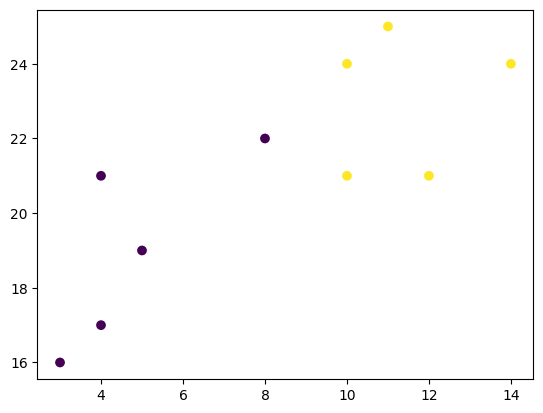

KNeighborsClassifier(n_neighbors=1)

In [2]:
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier


x = [4, 5, 10, 4, 3, 11, 14 , 8, 10, 12]
y = [21, 19, 24, 17, 16, 25, 24, 22, 21, 21]
classes = [0, 0, 1, 0, 0, 1, 1, 0, 1, 1]

plt.scatter(x, y, c=classes)
plt.show()

data = list(zip(x, y))
knn = KNeighborsClassifier(n_neighbors=1)

knn.fit(data, classes)



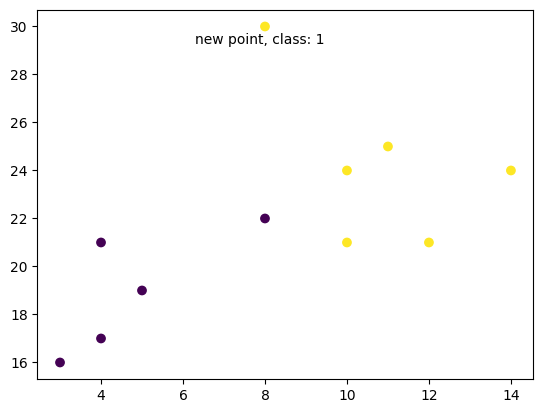

In [3]:
new_x = 8
new_y = 30
new_point = [(new_x, new_y)]

prediction = knn.predict(new_point)

plt.scatter(x + [new_x], y + [new_y], c=classes + [prediction[0]])
plt.text(x=new_x-1.7, y=new_y-0.7, s=f"new point, class: {prediction[0]}")
plt.show()

### **K-Means Algorithm (Simple)**

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans

# 1. Prepare the Data
x = [4, 5, 10, 4, 3, 11, 14 , 8, 10, 12]
y = [21, 19, 24, 17, 16, 25, 24, 22, 21, 21]
data_array = np.array(list(zip(x, y)))



# 2. Train and Predict
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans.fit(data_array)


KMeans(n_clusters=2, n_init=10, random_state=42)

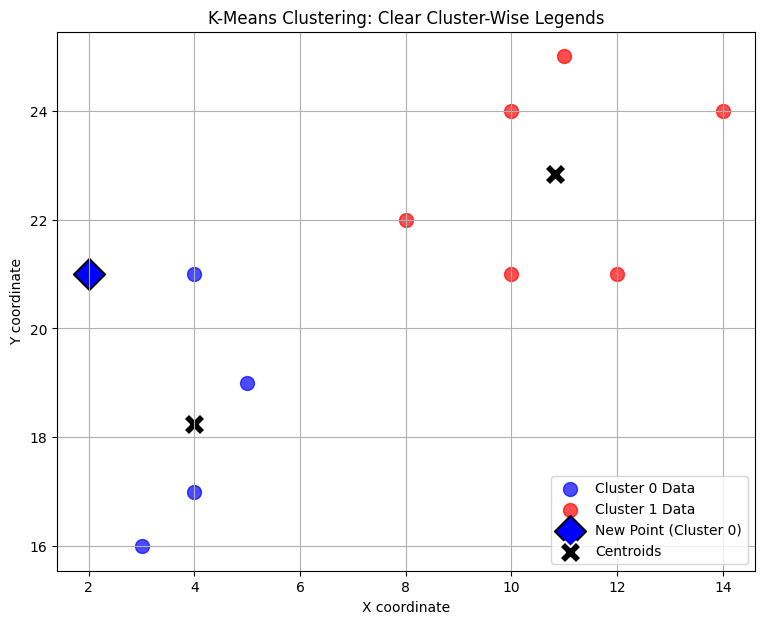


New Point (2, 21) was assigned to Cluster: 0


In [5]:
# New point to be clustered
new_x = 2
new_y = 21
new_point = np.array([[new_x, new_y]])

prediction = kmeans.predict(new_point)[0]
cluster_labels = kmeans.labels_
centroids = kmeans.cluster_centers_

# 3. Combine Data and Separate by Cluster
# Append the new point to the existing data and labels for plotting
x_all = np.array(x + [new_x])
y_all = np.array(y + [new_y])
c_all = np.append(cluster_labels, prediction)

# Separate the data points based on their assigned cluster label
cluster_0_indices = c_all == 0
cluster_1_indices = c_all == 1

# 4. Visualization with Separate Legends
plt.figure(figsize=(9, 7))

# Plot Cluster 0 points (blue)
plt.scatter(x_all[cluster_0_indices], y_all[cluster_0_indices],
            c='blue', s=100, label='Cluster 0 Data', alpha=0.7)

# Plot Cluster 1 points (orange/red)
plt.scatter(x_all[cluster_1_indices], y_all[cluster_1_indices],
            c='red', s=100, label='Cluster 1 Data', alpha=0.7)

# Plot the new point separately, using its predicted color
new_point_color = 'blue' if prediction == 0 else 'red'
plt.scatter(new_x, new_y, marker='D', s=250, color=new_point_color,
            edgecolor='black', linewidth=1.5, label=f'New Point (Cluster {prediction})')

# Plot the Centroids
plt.scatter(centroids[:, 0], centroids[:, 1], marker='X', s=250, color='black',
            label='Centroids', edgecolor='white', linewidth=1.5)

# Add labels and title
plt.title('K-Means Clustering: Clear Cluster-Wise Legends')
plt.xlabel('X coordinate')
plt.ylabel('Y coordinate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"\nNew Point ({new_x}, {new_y}) was assigned to Cluster: {prediction}")

### **Color Image segnmtation**

In [ ]:
!pip install opencv-python numpy scikit-learn matplotlib

--- Starting K-Means Clustering (K=20) ---

--- Iteration 1 ---
Paused for 0.5 seconds to view result...
New Centroid 0: [184 189 133]
New Centroid 1: [49 88 42]
New Centroid 2: [140  92  70]
New Centroid 3: [234 219 215]
New Centroid 4: [216 143 182]
New Centroid 5: [226 181 225]
New Centroid 6: [ 67 120  68]
New Centroid 7: [220 114 200]
New Centroid 8: [32 57 21]
New Centroid 9: [248 237 249]
New Centroid 10: [107 157 116]
New Centroid 11: [11 19  5]
New Centroid 12: [181 135 175]
New Centroid 13: [162   8  57]
New Centroid 14: [ 94 119  98]
New Centroid 15: [199  62 146]
New Centroid 16: [106  18  24]
New Centroid 17: [248 233  16]
New Centroid 18: [189 125  16]
New Centroid 19: [184  23  99]

--- Iteration 2 ---
Paused for 0.5 seconds to view result...
Converged: Centroids did not change in this step.


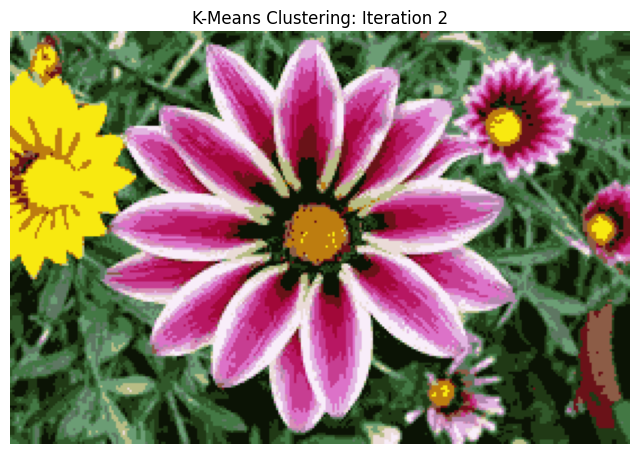


--- Clustering Finished in 2 Iterations ---
Final Centroids (RGB):
Cluster 0: [184 189 133]
Cluster 1: [49 88 42]
Cluster 2: [140  92  70]
Cluster 3: [234 219 215]
Cluster 4: [216 143 182]
Cluster 5: [226 181 225]
Cluster 6: [ 67 120  68]
Cluster 7: [220 114 200]
Cluster 8: [32 57 21]
Cluster 9: [248 237 249]
Cluster 10: [107 157 116]
Cluster 11: [11 19  5]
Cluster 12: [181 135 175]
Cluster 13: [162   8  57]
Cluster 14: [ 94 119  98]
Cluster 15: [199  62 146]
Cluster 16: [106  18  24]
Cluster 17: [248 233  16]
Cluster 18: [189 125  16]
Cluster 19: [184  23  99]


In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import time
from sklearn.cluster import KMeans

# --- Configuration ---
image_path = 'images.jpg'  # <-- REPLACE with your image path!
K = 20                      # Number of clusters (colors)
MAX_ITERATIONS = 10        # Limit the number of iterations for observation

def apply_kmeans_stepwise(image, K, max_iter):
    """
    Performs K-Means clustering on the image colors and displays
    the result after each iteration.
    """

    print(f"--- Starting K-Means Clustering (K={K}) ---")

    # 1. Prepare Data
    # Convert image from BGR (OpenCV format) to RGB for better visualization
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Reshape the image to a 2D array of pixels (N rows, 3 columns for R, G, B)
    rows, cols, channels = image_rgb.shape
    pixel_data = image_rgb.reshape(-1, 3)
    pixel_data = np.float32(pixel_data)

    # Initialize K-Means object for a single run
    # Set max_iter=1 to control the execution loop manually
    # n_init=1 is sufficient for manual iteration
    kmeans_model = KMeans(n_clusters=K, init='random',
                          max_iter=1, random_state=42, n_init=1)

    # Initial fit to get the starting centroids
    kmeans_model.fit(pixel_data)
    initial_centroids = kmeans_model.cluster_centers_

    # Start the actual iterative loop
    current_centroids = initial_centroids

    # Create figure for dynamic plotting
    fig, ax = plt.subplots(figsize=(8, 6))
    plt.ion() # Turn on interactive mode for live updates
    fig.show()

    for i in range(1, max_iter + 1):
        print(f"\n--- Iteration {i} ---")

        # --- E-Step: Assign points to the closest centroid ---
        # Calculate distances and find the closest centroid index for each pixel
        # We manually calculate labels based on current_centroids
        from sklearn.metrics import pairwise_distances_argmin
        labels = pairwise_distances_argmin(pixel_data, current_centroids)

        # --- Visualization ---
        # Reconstruct the image using the current centroids
        clustered_image_data = current_centroids[labels].astype(np.uint8)
        clustered_image = clustered_image_data.reshape(rows, cols, 3)

        # Update the plot
        ax.clear()
        ax.imshow(clustered_image)
        ax.set_title(f'K-Means Clustering: Iteration {i}')
        ax.axis('off')
        fig.canvas.draw()
        fig.canvas.flush_events()

        print(f"Paused for 0.5 seconds to view result...")
        time.sleep(0.5) # Pause execution

        # Check for convergence (no change in centroids)
        if i > 1 and np.allclose(current_centroids, new_centroids):
            print("Converged: Centroids did not change in this step.")
            break

        # --- M-Step: Calculate new centroids ---
        # Calculate the mean of all points assigned to each cluster
        new_centroids = np.zeros_like(current_centroids)
        for k in range(K):
            new_centroids[k] = pixel_data[labels == k].mean(axis=0)
            print(f"New Centroid {k}: {new_centroids[k].astype(int)}")

        # Update centroids for the next iteration
        current_centroids = new_centroids

    plt.ioff() # Turn off interactive mode
    plt.show() # Keep the final plot open

    print(f"\n--- Clustering Finished in {i} Iterations ---")
    print("Final Centroids (RGB):")
    for k, center in enumerate(current_centroids):
        print(f"Cluster {k}: {center.astype(int)}")

# --- Main Execution Block ---
try:
    # Read the image
    img = cv2.imread(image_path)

    if img is None:
        raise FileNotFoundError(f"Error: Could not read image at '{image_path}'. Check the path.")

    # Run the iterative K-Means function
    apply_kmeans_stepwise(img, K, MAX_ITERATIONS)

except FileNotFoundError as e:
    print(e)
    print("Please make sure you have an image file (e.g., 'my_image.jpg') in the same folder or update the 'image_path' variable.")
except Exception as e:
    print(f"An error occurred: {e}")